In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

In [2]:
#load CSV File 
data = pd.read_csv("dataset.csv") 
print(data.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
print(data.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [5]:
print(data.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
data["TotalCharges"].head(200)

0        29.85
1       1889.5
2       108.15
3      1840.75
4       151.65
        ...   
195    1901.65
196      587.4
197    6519.75
198    8041.65
199      20.75
Name: TotalCharges, Length: 200, dtype: object

In [7]:
#NOTE:Fix hidden text trap in TotalCharges
# Why? New customers have blank spaces (" ") instead of numbers, making the whole column an 'object' type.
# pd.to_numeric forces spaces to become NaN so we can handle them, avoiding a StandardScaler crash later!
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
# errors='coerce' turns any non-numeric data (like blank spaces or text) into NaN instead of crashing the code.

data.dropna(inplace=True)

print("After dropping the Data:", data.shape[0])

After dropping the Data: 7032


In [8]:
data.drop(columns=['customerID'], inplace=True)

print(data.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [9]:

print(data["Churn"].value_counts())

Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [10]:
data.isnull().sum()
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [1]:

# le = LabelEncoder()
# data['Churn'] = le.fit_transform(data['Churn'])
# binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
# for col in binary_cols:
#     #data[col] = le.fit_transform(data[col])
#     # OR 
#     data[col] = data[col].map({'No': 0, 'Yes': 1})
# data['gender'] = data['gender'].map({'Female': 0, 'Male': 1})

# multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
#               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
# data = pd.get_dummies(data, columns=multi_cols, drop_first=True)
        

In [11]:

main_mapping = {'No': 0, 'Yes': 1, 'Female': 0, 'Male': 1}

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']


for col in binary_cols:
    data[col] = data[col].map(main_mapping)

# pd.get_dummies splits multi-option columns into separate 0 and 1 columns.
# Why? It treats all categories equally, so the model doesn't think one category is "greater than" another.
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
data = pd.get_dummies(data, columns=multi_cols, drop_first=True)


In [12]:
3# 'Churn' column is dropped from X and moved to y. 
# All other cleaned, mapped, scaled, and dummy columns remain in X to train the model.
X = data.drop(columns=['Churn'])
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
## StandardScaler brings columns like tenure and charges to the same scale (Mean=0, SD=1).
# We fit_transform on X_train to learn patterns, but ONLY transform on X_test to prevent Data Leakage.
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [15]:
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
print("RESULT OF LOGISTIC REGRESSION")
print(f"Accuracy Score: {accuracy_score(y_test,y_pred_log):.4f}")
print("\nClassification Report:\n" , classification_report(y_test,y_pred_log))

RESULT OF LOGISTIC REGRESSION
Accuracy Score: 0.7868

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [16]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf=rf_model.predict(X_test)
print("RESULT OF RANDOMFOREST")
print(f"Accuracy Score: {accuracy_score (y_test,y_pred_rf):.4f}")
print("nClassification Report:\n" , classification_report(y_test,y_pred_rf))

RESULT OF RANDOMFOREST
Accuracy Score: 0.7868
nClassification Report:
               precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.64      0.46      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407




# FINAL MODEL COMPARISON & SELECTION CRITERIA (Why Logistic Regression Wins)

# 1. ACCURACY: Both models give the exact same overall accuracy of 78.68%.
#    This means both predict roughly 79 out of 100 customers correctly.

# 2. THE CHURN CHALLENGE (Class 1): Our main goal is to catch customers who will LEAVE.
#    - Logistic Regression Recall = 51% (Catches 51% of actual churners)
#    - Random Forest Recall = 46% (Catches only 46% of actual churners)

# 3. BUSINESS IMPACT: In Telecom Churn, missing a leaving customer costs more money
#    than accidentally giving a discount to a loyal customer. 
#    Therefore, we need HIGHER RECALL to catch as many churners as possible.

# FINAL VERDICT: We choose Logistic Regression because its higher Recall (51% vs 46%)
# and higher F1-Score (0.56 vs 0.54) make it better at solving the actual business problem.

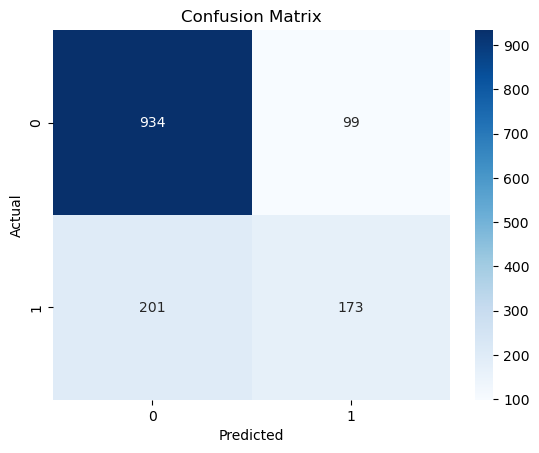

In [17]:
cm = confusion_matrix(y_test ,y_pred_rf)
sns.heatmap(cm, annot = True, fmt = "d" ,cmap = "Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#  SAVE LOGISTIC REGRESSION MODEL
joblib.dump(log_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("\nSaved: model.pkl, scaler.pkl, feature_columns.pkl")